# Week 7 — Advanced Models

Week 6 showed that LightGBM performed best after adding historical location and nearby-sale information. This notebook uses Optuna to lightly tune that model, chooses the best settings using February through April 2026 validation data, and then evaluates the selected model once on May 2026.

The same AVM restrictions still apply: listing price, original listing price, and days on market are excluded.

In [1]:
from pathlib import Path
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import optuna
from optuna.importance import get_param_importances
import pandas as pd
import seaborn as sns

from lightgbm import LGBMRegressor, early_stopping
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

/Users/jadenwu/Desktop/IdxExchange/myRepo/IdxExchange/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the data and confirm the split

In [2]:
DATA_FILE = Path("data/week5_unstandardized_model_data.csv")
TUNING_RESULTS_FILE = Path("data/week7_optuna_trials.csv")
VALIDATION_RESULTS_FILE = Path("data/week7_validation_model_comparison.csv")
TEST_RESULTS_FILE = Path("data/week7_final_test_metrics.csv")
BEST_PARAMS_FILE = Path("data/week7_best_lightgbm_params.json")
MODEL_FILE = Path("data/week7_tuned_lightgbm.joblib")
FEATURE_IMPORTANCE_FILE = Path("data/week7_feature_importance.csv")
VALIDATION_PLOT_FILE = Path("data/week7_validation_comparison.png")
TUNING_PLOT_FILE = Path("data/week7_optuna_summary.png")
TEST_PLOT_FILE = Path("data/week7_test_diagnostics.png")

TRAIN_MONTHS = pd.period_range("2025-02", "2026-01", freq="M").astype(str).tolist()
VALIDATION_MONTHS = pd.period_range("2026-02", "2026-04", freq="M").astype(str).tolist()
TEST_MONTHS = ["2026-05"]
RANDOM_STATE = 42
N_TRIALS = 20

df = pd.read_csv(DATA_FILE, low_memory=False)
expected_months = {
    "train": TRAIN_MONTHS,
    "validation": VALIDATION_MONTHS,
    "test": TEST_MONTHS,
}
for split_name, expected in expected_months.items():
    actual = sorted(df.loc[df["split"] == split_name, "close_month"].unique())
    assert actual == expected, (split_name, actual, expected)

train_raw = df[df["split"] == "train"].copy()
validation_raw = df[df["split"] == "validation"].copy()
test_raw = df[df["split"] == "test"].copy()

# Continue using the training-only top 0.5% cutoff selected earlier.
UPPER_CUTOFF = train_raw["ClosePrice"].quantile(0.995)
train_raw = train_raw[train_raw["ClosePrice"] <= UPPER_CUTOFF].copy()
validation_raw = validation_raw[validation_raw["ClosePrice"] <= UPPER_CUTOFF].copy()
test_coverage = (test_raw["ClosePrice"] <= UPPER_CUTOFF).mean()
test_raw = test_raw[test_raw["ClosePrice"] <= UPPER_CUTOFF].copy()

print(f"Train:      {len(train_raw):,} rows ({TRAIN_MONTHS[0]} to {TRAIN_MONTHS[-1]})")
print(f"Validation: {len(validation_raw):,} rows ({VALIDATION_MONTHS[0]} to {VALIDATION_MONTHS[-1]})")
print(f"Test:       {len(test_raw):,} rows ({TEST_MONTHS[0]})")
print(f"Upper cutoff: ${UPPER_CUTOFF:,.0f}")
print(f"Test coverage under cutoff: {test_coverage:.2%}")

Train:      128,797 rows (2025-02 to 2026-01)
Validation: 31,554 rows (2026-02 to 2026-04)
Test:       11,959 rows (2026-05)
Upper cutoff: $8,200,000
Test coverage under cutoff: 99.55%


## Week 6 feature set

The model starts with the original property fields and adds the location features retained in Week 6: historical price per square foot and sale volume for four geographic groupings, plus information from the 25 nearest historical sales.

Each training row receives out-of-fold location values. Validation and test rows are built only from earlier development data.

In [3]:
BASE_NUMERIC = [
    "Latitude", "Longitude", "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger", "HomeAge", "Stories",
    "GarageSpaces", "ParkingTotal", "AssociationFee",
    "LotSizeSquareFeet", "LotSizeAcres", "MainLevelBedrooms",
]
BASE_BOOLEAN = [
    "ViewYN", "WaterfrontYN", "PoolPrivateYN", "AttachedGarageYN",
    "FireplaceYN", "NewConstructionYN",
]
BASE_CATEGORICAL = [
    "City", "PostalCode", "CountyOrParish", "MLSAreaMajor",
    "HighSchoolDistrict", "Levels",
]
LOCATION_GROUPS = ["PostalCode", "MLSAreaMajor", "City", "HighSchoolDistrict"]
LOCATION_SMOOTHING = 40
KNN_NEIGHBORS = 25
EXCLUDED_COLUMNS = {"ListPrice", "OriginalListPrice", "DaysOnMarket"}
assert EXCLUDED_COLUMNS.isdisjoint(BASE_NUMERIC + BASE_BOOLEAN + BASE_CATEGORICAL)

for frame in (train_raw, validation_raw, test_raw):
    for column in BASE_CATEGORICAL:
        frame[column] = frame[column].fillna("Unknown").astype(str)

### Historical location features

In [4]:
def sale_ppsf(frame):
    values = frame["ClosePrice"] / frame["LivingArea"].where(frame["LivingArea"] > 0)
    return values.where(values.between(10, 5_000))


def fit_location_lookup(source, group_column, smoothing=LOCATION_SMOOTHING):
    work = pd.DataFrame({
        "group": source[group_column].astype(str),
        "ppsf": sale_ppsf(source),
    }).dropna()
    overall = work["ppsf"].median()
    stats = work.groupby("group")["ppsf"].agg(["median", "count"])
    stats["smoothed_ppsf"] = (
        stats["median"] * stats["count"] + overall * smoothing
    ) / (stats["count"] + smoothing)
    return stats["smoothed_ppsf"], stats["count"], overall


def add_location_history(reference, future, n_splits=5):
    reference_out = reference.copy()
    future_out = future.copy()
    folds = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    saved_lookups = {}

    for group_column in LOCATION_GROUPS:
        ppsf_column = f"{group_column}_area_ppsf"
        count_column = f"{group_column}_sales_log"
        value_column = f"{group_column}_value_anchor"
        reference_out[ppsf_column] = np.nan
        reference_out[count_column] = np.nan

        for fit_positions, holdout_positions in folds.split(reference):
            fit_rows = reference.iloc[fit_positions]
            holdout_index = reference.index[holdout_positions]
            ppsf_map, count_map, overall = fit_location_lookup(fit_rows, group_column)
            keys = reference.loc[holdout_index, group_column].astype(str)
            reference_out.loc[holdout_index, ppsf_column] = (
                keys.map(ppsf_map).fillna(overall).to_numpy()
            )
            reference_out.loc[holdout_index, count_column] = np.log1p(
                keys.map(count_map).fillna(0).to_numpy()
            )

        ppsf_map, count_map, overall = fit_location_lookup(reference, group_column)
        future_keys = future[group_column].astype(str)
        future_out[ppsf_column] = future_keys.map(ppsf_map).fillna(overall)
        future_out[count_column] = np.log1p(future_keys.map(count_map).fillna(0))
        reference_out[value_column] = reference_out[ppsf_column] * reference_out["LivingArea"]
        future_out[value_column] = future_out[ppsf_column] * future_out["LivingArea"]
        saved_lookups[group_column] = {
            "ppsf": ppsf_map.to_dict(),
            "count": count_map.to_dict(),
            "overall_ppsf": float(overall),
        }

    return reference_out, future_out, saved_lookups


LOCATION_HISTORY_FEATURES = [
    feature
    for group in LOCATION_GROUPS
    for feature in (
        f"{group}_area_ppsf", f"{group}_sales_log", f"{group}_value_anchor"
    )
]

### Nearby comparable-sale features

In [5]:
def fit_neighbor_reference(reference, neighbors=KNN_NEIGHBORS):
    usable = (
        reference[["Latitude", "Longitude"]].notna().all(axis=1)
        & sale_ppsf(reference).notna()
    )
    coordinates = np.radians(
        reference.loc[usable, ["Latitude", "Longitude"]].to_numpy()
    )
    targets = sale_ppsf(reference.loc[usable]).to_numpy()
    model = NearestNeighbors(
        n_neighbors=neighbors, algorithm="ball_tree", metric="haversine", n_jobs=-1
    )
    model.fit(coordinates)
    return model, targets


def neighbor_estimates(model, reference_targets, query, coordinate_medians):
    coordinates = (
        query[["Latitude", "Longitude"]]
        .fillna(coordinate_medians)
        .to_numpy()
    )
    distances, positions = model.kneighbors(np.radians(coordinates))
    nearby_prices = reference_targets[positions]
    weights = 1.0 / np.maximum(distances, 1e-6)
    estimated_ppsf = np.sum(weights * nearby_prices, axis=1) / np.sum(weights, axis=1)
    median_distance_km = np.median(distances, axis=1) * 6_371.0
    return estimated_ppsf, median_distance_km


def add_neighbor_features(reference, future, n_splits=5):
    reference_out = reference.copy()
    future_out = future.copy()
    ppsf_column = "nearby_25_ppsf"
    distance_column = "nearby_25_distance_km"
    value_column = "nearby_25_value_anchor"
    reference_out[ppsf_column] = np.nan
    reference_out[distance_column] = np.nan
    folds = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    for fit_positions, holdout_positions in folds.split(reference):
        fit_rows = reference.iloc[fit_positions]
        holdout_rows = reference.iloc[holdout_positions]
        coordinate_medians = fit_rows[["Latitude", "Longitude"]].median()
        neighbor_model, reference_targets = fit_neighbor_reference(fit_rows)
        ppsf_values, distance_values = neighbor_estimates(
            neighbor_model, reference_targets, holdout_rows, coordinate_medians
        )
        reference_out.loc[holdout_rows.index, ppsf_column] = ppsf_values
        reference_out.loc[holdout_rows.index, distance_column] = distance_values

    coordinate_medians = reference[["Latitude", "Longitude"]].median()
    final_neighbor_model, final_reference_targets = fit_neighbor_reference(reference)
    future_ppsf, future_distance = neighbor_estimates(
        final_neighbor_model, final_reference_targets, future, coordinate_medians
    )
    future_out[ppsf_column] = future_ppsf
    future_out[distance_column] = future_distance
    reference_out[value_column] = reference_out[ppsf_column] * reference_out["LivingArea"]
    future_out[value_column] = future_out[ppsf_column] * future_out["LivingArea"]

    saved_reference = {
        "model": final_neighbor_model,
        "reference_ppsf": final_reference_targets,
        "coordinate_medians": coordinate_medians,
        "neighbors": KNN_NEIGHBORS,
    }
    return reference_out, future_out, saved_reference


NEIGHBOR_FEATURES = [
    "nearby_25_ppsf", "nearby_25_distance_km", "nearby_25_value_anchor"
]

## Build training and validation features

In [6]:
train_features, validation_features, training_location_lookups = add_location_history(
    train_raw, validation_raw
)
train_features, validation_features, training_neighbor_reference = add_neighbor_features(
    train_features, validation_features
)

NUMERIC_FEATURES = BASE_NUMERIC + LOCATION_HISTORY_FEATURES + NEIGHBOR_FEATURES
ALL_FEATURES = NUMERIC_FEATURES + BASE_BOOLEAN + BASE_CATEGORICAL

print(f"Original features: {len(BASE_NUMERIC) + len(BASE_BOOLEAN) + len(BASE_CATEGORICAL)}")
print(f"Location features added: {len(LOCATION_HISTORY_FEATURES) + len(NEIGHBOR_FEATURES)}")
print(f"Final feature count: {len(ALL_FEATURES)}")
train_features[LOCATION_HISTORY_FEATURES + NEIGHBOR_FEATURES].describe().T

Original features: 26
Location features added: 15
Final feature count: 41


,count,mean,std,min,25%,50%,75%,max
PostalCode_area_ppsf,"128,797.0000",556.1348,205.7449,261.9034,394.9593,532.6033,663.3842,"1,462.4204"
PostalCode_sales_log,"128,797.0000",4.9623,0.8534,0.0000,4.5433,5.0999,5.5053,6.6490
PostalCode_value_anchor,"128,741.0000","1,140,906.7805","780,530.0973",0.0000,"647,203.9568","920,618.6033","1,378,186.0455","22,579,205.9280"
MLSAreaMajor_area_ppsf,"128,797.0000",549.3080,180.1100,252.9405,429.8540,517.7965,644.9118,"1,437.8403"
MLSAreaMajor_sales_log,"128,797.0000",6.3024,2.1220,0.0000,4.8122,5.5722,8.6654,9.6246
MLSAreaMajor_value_anchor,"128,741.0000","1,121,313.1673","724,997.4321",0.0000,"661,804.7211","930,601.2855","1,355,538.5328","21,468,498.7508"
City_area_ppsf,"128,797.0000",565.1416,225.6033,252.5011,385.0081,541.1497,705.7870,"1,686.7453"
City_sales_log,"128,797.0000",5.8462,1.2483,0.0000,5.1705,5.8805,6.6386,8.3526
City_value_anchor,"128,741.0000","1,156,129.6342","803,451.3581",0.0000,"642,096.1798","936,333.7157","1,409,329.5006","22,579,205.9280"
HighSchoolDistrict_area_ppsf,"128,797.0000",557.4149,183.5096,254.5656,397.6988,593.7956,610.8166,"1,670.3205"


## Prepare the model matrix

The imputer and category encoder are fitted on the training period only. The transformed validation matrix is reused for every Optuna trial so the search compares model settings rather than repeatedly changing preprocessing.

In [7]:
def make_preprocessor():
    return ColumnTransformer([
        ("numeric", SimpleImputer(
            strategy="median", keep_empty_features=True
        ), NUMERIC_FEATURES),
        ("boolean", SimpleImputer(
            strategy="most_frequent", keep_empty_features=True
        ), BASE_BOOLEAN),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1,
                encoded_missing_value=-1,
            )),
        ]), BASE_CATEGORICAL),
    ], verbose_feature_names_out=True)


preprocessor = make_preprocessor()
X_train = preprocessor.fit_transform(train_features)
X_validation = preprocessor.transform(validation_features)
y_train = train_features["ClosePrice"].to_numpy()
y_validation = validation_features["ClosePrice"].to_numpy()

print(f"Training matrix: {X_train.shape}")
print(f"Validation matrix: {X_validation.shape}")

Training matrix: (128797, 41)
Validation matrix: (31554, 41)


## Week 6 LightGBM baseline

In [8]:
def regression_metrics(actual, predicted):
    residual = np.asarray(actual) - np.asarray(predicted)
    expensive = np.asarray(actual) >= 1_500_000
    return {
        "r2": r2_score(actual, predicted),
        "mae": mean_absolute_error(actual, predicted),
        "rmse": float(np.sqrt(mean_squared_error(actual, predicted))),
        "mae_1_5m_plus": float(np.mean(np.abs(residual[expensive]))),
        "mean_residual_1_5m_plus": float(np.mean(residual[expensive])),
        "underprediction_rate_1_5m_plus": float(np.mean(residual[expensive] > 0)),
    }


DEFAULT_PARAMS = {
    "n_estimators": 400,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "subsample": 0.85,
    "subsample_freq": 1,
    "colsample_bytree": 0.85,
    "reg_lambda": 1.0,
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
    "verbosity": -1,
}

default_model = LGBMRegressor(**DEFAULT_PARAMS)
default_model.fit(X_train, y_train)
default_validation_predictions = default_model.predict(X_validation)
default_validation_metrics = regression_metrics(
    y_validation, default_validation_predictions
)
pd.Series(default_validation_metrics, name="Week 6 baseline")

r2                                     0.9085
mae                              156,084.2870
rmse                             293,144.4854
mae_1_5m_plus                    356,512.3614
mean_residual_1_5m_plus          126,576.5924
underprediction_rate_1_5m_plus         0.6431
Name: Week 6 baseline, dtype: float64

## Optuna search

The search is intentionally light. It varies tree depth, learning rate, number of boosting rounds, leaf count, minimum leaf size, row and column sampling, and L1/L2 regularization. Validation R² is the selection metric. Early stopping prevents unnecessarily long trials.

In [9]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1_000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.015, 0.12, log=True),
        "max_depth": trial.suggest_int("max_depth", 5, 12),
        "num_leaves": trial.suggest_int("num_leaves", 31, 160),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100, step=10),
        "subsample": trial.suggest_float("subsample", 0.70, 1.00),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
        "verbosity": -1,
    }
    model = LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_validation, y_validation)],
        eval_metric="rmse",
        callbacks=[early_stopping(50, verbose=False)],
    )
    predictions = model.predict(X_validation)
    metrics = regression_metrics(y_validation, predictions)
    trial.set_user_attr("mae", metrics["mae"])
    trial.set_user_attr("rmse", metrics["rmse"])
    trial.set_user_attr("best_iteration", int(model.best_iteration_ or params["n_estimators"]))
    return metrics["r2"]


sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="maximize", sampler=sampler)
tuning_started = time.perf_counter()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
tuning_seconds = time.perf_counter() - tuning_started

trials_df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs", "duration"))
trials_df.to_csv(TUNING_RESULTS_FILE, index=False)

print(f"Completed {len(study.trials)} trials in {tuning_seconds / 60:.1f} minutes")
print(f"Best validation R²: {study.best_value:.4f}")
print(f"Best trial: {study.best_trial.number}")
pd.Series(study.best_params, name="best_value")

Completed 20 trials in 2.7 minutes
Best validation R²: 0.9110
Best trial: 11


n_estimators        1,000.0000
learning_rate           0.0493
max_depth               7.0000
num_leaves            155.0000
min_child_samples      60.0000
subsample               0.9990
colsample_bytree        0.9260
reg_alpha               0.0786
reg_lambda              9.8705
Name: best_value, dtype: float64

## Tuning results

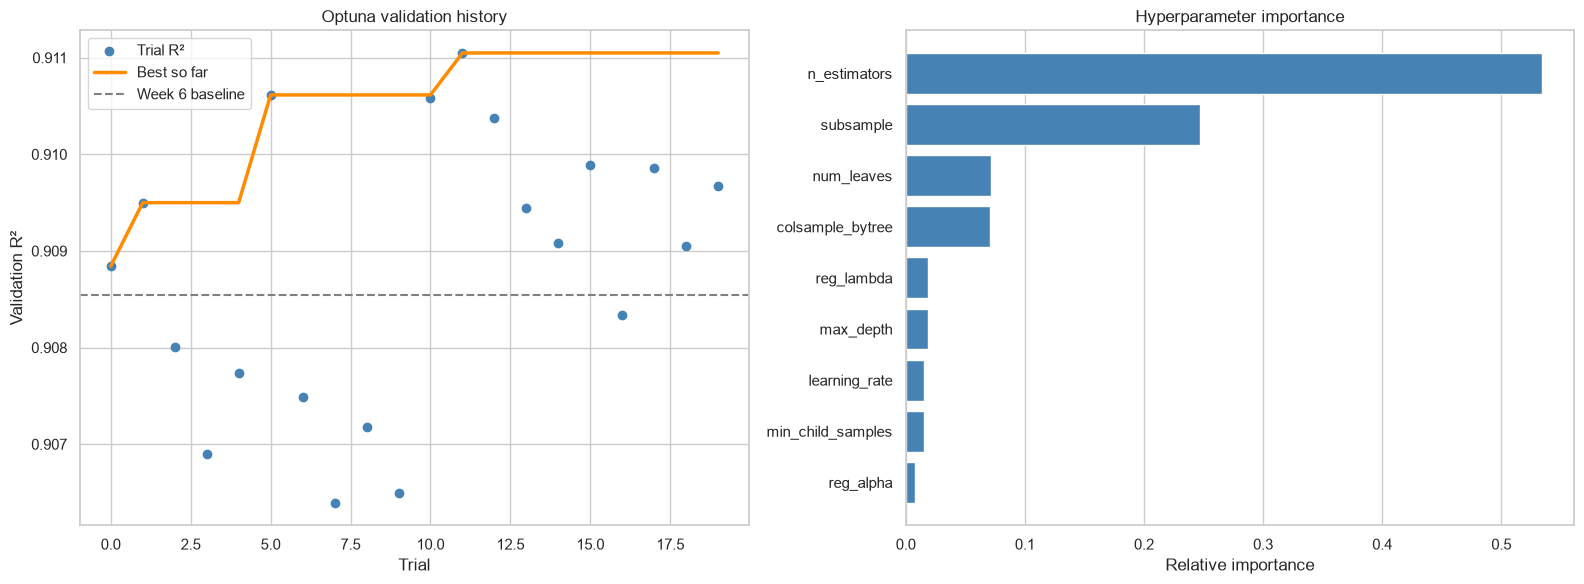

In [10]:
completed_trials = [trial for trial in study.trials if trial.value is not None]
trial_numbers = [trial.number for trial in completed_trials]
trial_scores = [trial.value for trial in completed_trials]
running_best = np.maximum.accumulate(trial_scores)
parameter_importance = get_param_importances(study)
importance_names = list(parameter_importance.keys())[::-1]
importance_values = [parameter_importance[name] for name in importance_names]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(trial_numbers, trial_scores, color="steelblue", label="Trial R²")
axes[0].plot(trial_numbers, running_best, color="darkorange", linewidth=2.5, label="Best so far")
axes[0].axhline(
    default_validation_metrics["r2"], color="gray", linestyle="--",
    label="Week 6 baseline",
)
axes[0].set_title("Optuna validation history")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Validation R²")
axes[0].legend()

axes[1].barh(importance_names, importance_values, color="steelblue")
axes[1].set_title("Hyperparameter importance")
axes[1].set_xlabel("Relative importance")
axes[1].set_ylabel("")
axes[1].grid(axis="y", visible=False)

fig.tight_layout()
fig.savefig(TUNING_PLOT_FILE, dpi=180, bbox_inches="tight")
plt.show()

## Refit the validation winner

This section trains the chosen configuration again and compares it directly with the Week 6 LightGBM settings on the same validation rows.

In [11]:
best_params = study.best_params.copy()
best_params.update({
    "subsample_freq": 1,
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
    "verbosity": -1,
})

tuned_model = LGBMRegressor(**best_params)
tuned_model.fit(
    X_train, y_train,
    eval_set=[(X_validation, y_validation)],
    eval_metric="rmse",
    callbacks=[early_stopping(50, verbose=False)],
)
tuned_validation_predictions = tuned_model.predict(X_validation)
tuned_validation_metrics = regression_metrics(
    y_validation, tuned_validation_predictions
)
best_iteration = int(tuned_model.best_iteration_ or best_params["n_estimators"])

validation_comparison = pd.DataFrame([
    {"model": "Week 6 LightGBM", **default_validation_metrics},
    {"model": "Optuna-tuned LightGBM", **tuned_validation_metrics},
])
validation_comparison["r2_change"] = (
    validation_comparison["r2"] - default_validation_metrics["r2"]
)
validation_comparison["mae_change"] = (
    validation_comparison["mae"] - default_validation_metrics["mae"]
)
validation_comparison.to_csv(VALIDATION_RESULTS_FILE, index=False)

serializable_params = {
    **study.best_params,
    "best_iteration": best_iteration,
    "validation_r2": tuned_validation_metrics["r2"],
}
BEST_PARAMS_FILE.write_text(json.dumps(serializable_params, indent=2))
print(f"Best boosting iteration: {best_iteration}")
validation_comparison

Best boosting iteration: 992


,model,r2,mae,rmse,mae_1_5m_plus,mean_residual_1_5m_plus,underprediction_rate_1_5m_plus,r2_change,mae_change
0,Week 6 LightGBM,0.9085,"156,084.2870","293,144.4854","356,512.3614","126,576.5924",0.6431,0.0000,0.0000
1,Optuna-tuned LightGBM,0.9110,"150,777.4265","289,104.8101","352,518.1016","122,349.3365",0.6403,0.0025,"-5,306.8604"


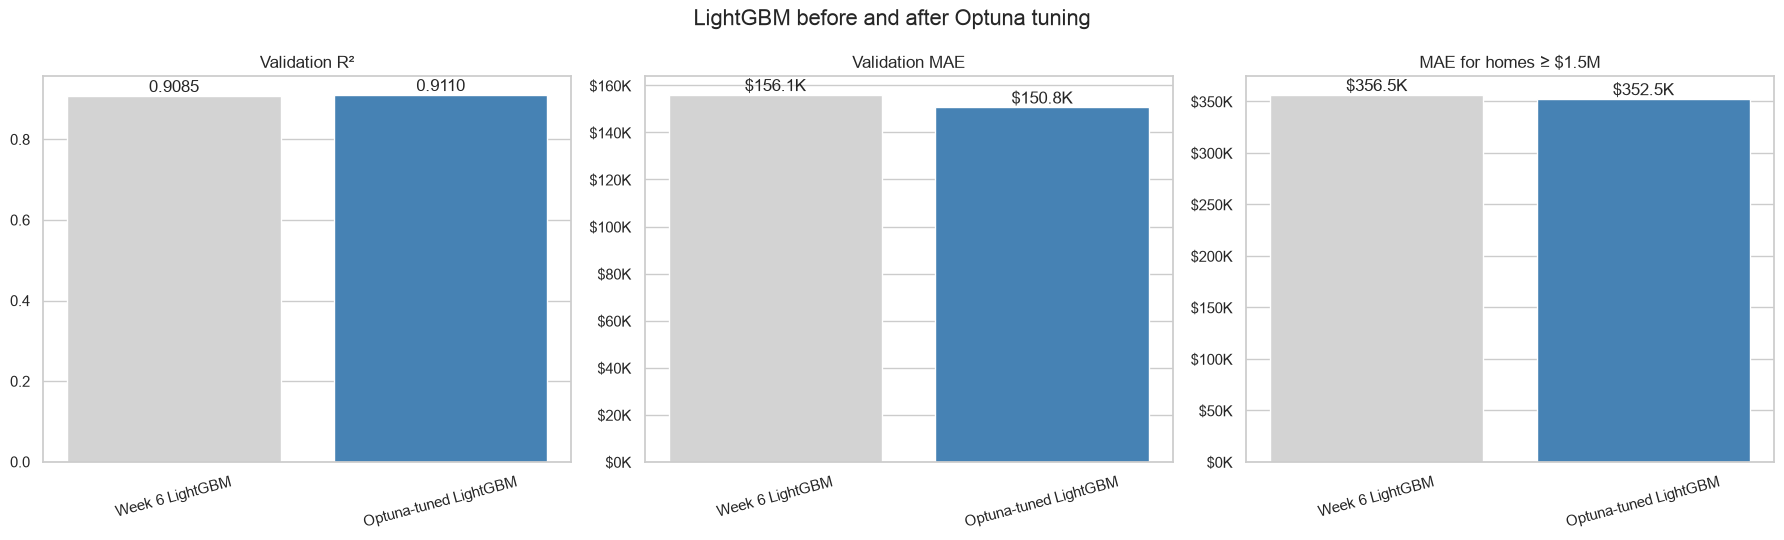

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
colors = ["lightgray", "steelblue"]
metrics_to_plot = [
    ("r2", "Validation R²", lambda value: f"{value:.4f}"),
    ("mae", "Validation MAE", lambda value: f"${value/1000:.1f}K"),
    ("mae_1_5m_plus", "MAE for homes ≥ $1.5M", lambda value: f"${value/1000:.1f}K"),
]
for axis, (column, title, formatter) in zip(axes, metrics_to_plot):
    bars = axis.bar(validation_comparison["model"], validation_comparison[column], color=colors)
    axis.set_title(title)
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=15)
    axis.grid(axis="x", visible=False)
    for bar, value in zip(bars, validation_comparison[column]):
        axis.text(bar.get_x() + bar.get_width()/2, bar.get_height(), formatter(value), ha="center", va="bottom")
    if column != "r2":
        axis.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value/1000:.0f}K"))

fig.suptitle("LightGBM before and after Optuna tuning", fontsize=16)
fig.tight_layout()
fig.savefig(VALIDATION_PLOT_FILE, dpi=180, bbox_inches="tight")
plt.show()

## Final May 2026 evaluation

The hyperparameters are now fixed. Training and validation rows are combined, the location features are rebuilt using the full development period, and the selected model is fitted one final time. May 2026 is used only for the metrics below.

In [13]:
development_raw = pd.concat([train_raw, validation_raw], ignore_index=True)
development_features, test_features, final_location_lookups = add_location_history(
    development_raw, test_raw
)
development_features, test_features, final_neighbor_reference = add_neighbor_features(
    development_features, test_features
)

final_preprocessor = make_preprocessor()
X_development = final_preprocessor.fit_transform(development_features)
X_test = final_preprocessor.transform(test_features)
y_development = development_features["ClosePrice"].to_numpy()
y_test = test_features["ClosePrice"].to_numpy()

final_params = best_params.copy()
final_params["n_estimators"] = best_iteration
final_model = LGBMRegressor(**final_params)
final_model.fit(X_development, y_development)
test_predictions = final_model.predict(X_test)
test_metrics = regression_metrics(y_test, test_predictions)

test_results = pd.DataFrame([{
    "model": "Optuna-tuned LightGBM",
    "test_month": TEST_MONTHS[0],
    "rows": len(test_features),
    "coverage": test_coverage,
    "upper_cutoff": UPPER_CUTOFF,
    **{f"test_{key}": value for key, value in test_metrics.items()},
}])
test_results.to_csv(TEST_RESULTS_FILE, index=False)
test_results.T

,0
model,Optuna-tuned LightGBM
test_month,2026-05
rows,11959
coverage,0.9955
upper_cutoff,"8,200,000.0000"
test_r2,0.9103
test_mae,"154,228.1993"
test_rmse,"293,097.3740"
test_mae_1_5m_plus,"353,284.8367"
test_mean_residual_1_5m_plus,"133,804.3073"


## Test residuals

Residual is actual price minus predicted price, so positive values indicate underprediction. Price-band MAE removes direction and shows the typical error size within each part of the market.

In [14]:
test_diagnostics = test_features[[
    "ListingId", "City", "PostalCode", "LivingArea",
    "BedroomsTotal", "BathroomsTotalInteger", "ClosePrice",
]].copy()
test_diagnostics["prediction"] = test_predictions
test_diagnostics["residual"] = test_diagnostics["ClosePrice"] - test_predictions
test_diagnostics["absolute_error"] = test_diagnostics["residual"].abs()

price_edges = [0, 250_000, 500_000, 750_000, 1_000_000, 1_500_000, 2_000_000, 3_000_000, 4_000_000, 6_000_000, UPPER_CUTOFF]
price_labels = [
    "Under $250K", "$250K–$500K", "$500K–$750K", "$750K–$1M",
    "$1M–$1.5M", "$1.5M–$2M", "$2M–$3M", "$3M–$4M",
    "$4M–$6M", f"$6M–${UPPER_CUTOFF/1e6:.1f}M",
]
test_diagnostics["price_band"] = pd.cut(
    test_diagnostics["ClosePrice"], bins=price_edges, labels=price_labels, include_lowest=True
)
band_results = test_diagnostics.groupby("price_band", observed=False).agg(
    rows=("ClosePrice", "size"),
    mean_actual=("ClosePrice", "mean"),
    mae=("absolute_error", "mean"),
    mean_residual=("residual", "mean"),
).reset_index()
band_results

,price_band,rows,mean_actual,mae,mean_residual
0,Under $250K,149,"184,383.7658","130,509.7810","-120,340.2353"
1,$250K–$500K,1547,"404,818.3607","54,232.7391","-29,039.2606"
2,$500K–$750K,2527,"631,915.8215","62,489.5230","-20,076.8570"
3,$750K–$1M,2372,"870,440.2454","84,676.2139","-20,487.2472"
4,$1M–$1.5M,2455,"1,242,768.6833","141,337.6075","5,281.8551"
5,$1.5M–$2M,1296,"1,728,250.9869","212,312.6919","16,981.8993"
6,$2M–$3M,932,"2,439,506.5665","325,153.2068","109,756.4615"
7,$3M–$4M,356,"3,448,741.7949","502,277.8900","187,662.0861"
8,$4M–$6M,262,"4,730,604.3092","675,836.6274","398,548.4221"
9,$6M–$8.2M,63,"6,966,111.4286","1,607,048.2211","1,599,558.0083"


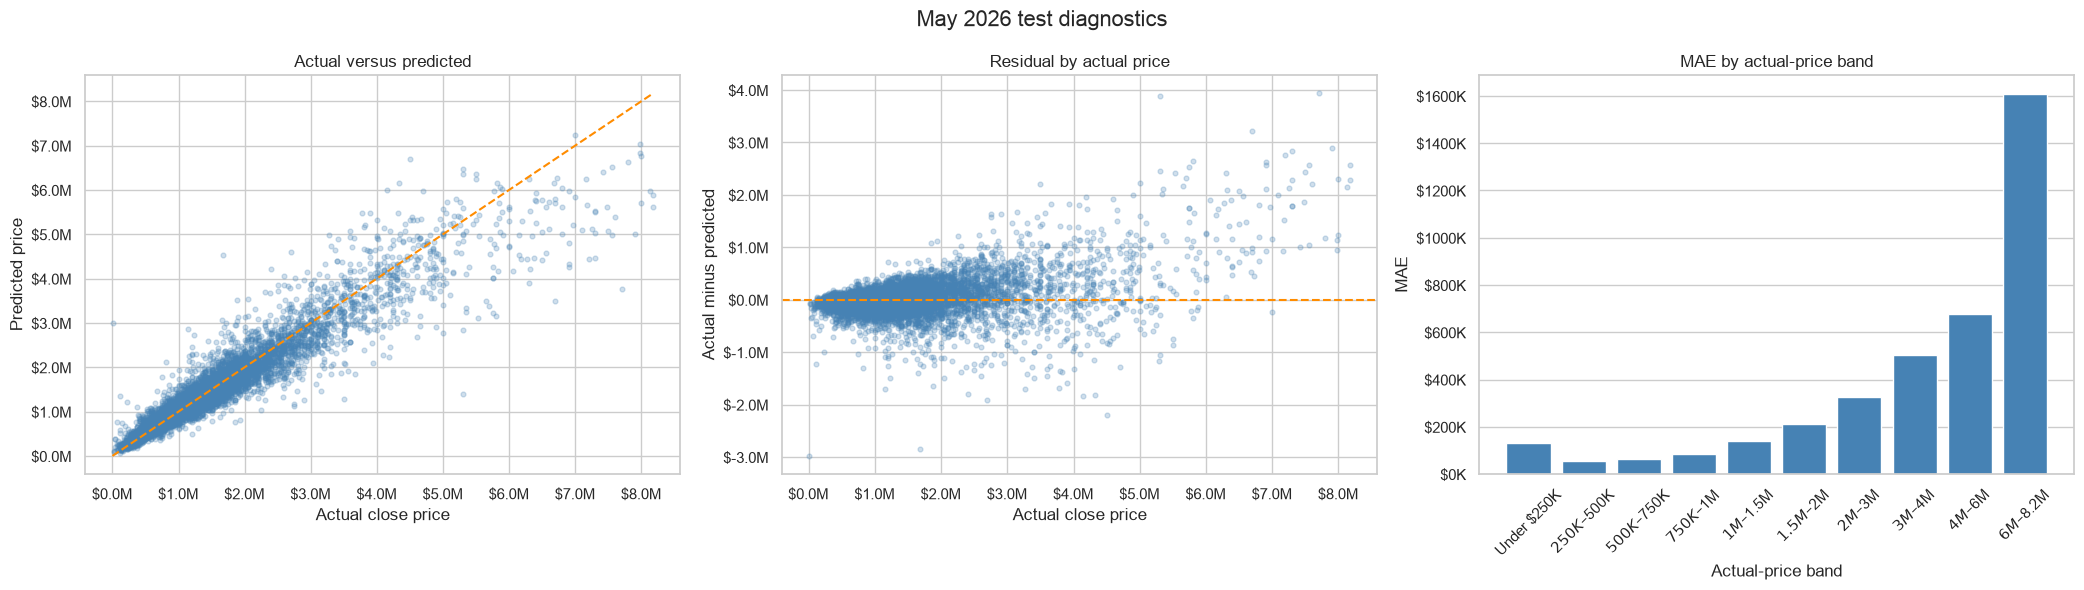

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

axes[0].scatter(y_test, test_predictions, alpha=0.25, s=12, color="steelblue")
limit = max(y_test.max(), test_predictions.max())
axes[0].plot([0, limit], [0, limit], color="darkorange", linestyle="--")
axes[0].set_title("Actual versus predicted")
axes[0].set_xlabel("Actual close price")
axes[0].set_ylabel("Predicted price")

axes[1].scatter(y_test, test_diagnostics["residual"], alpha=0.25, s=12, color="steelblue")
axes[1].axhline(0, color="darkorange", linestyle="--")
axes[1].set_title("Residual by actual price")
axes[1].set_xlabel("Actual close price")
axes[1].set_ylabel("Actual minus predicted")

axes[2].bar(band_results["price_band"].astype(str), band_results["mae"], color="steelblue")
axes[2].set_title("MAE by actual-price band")
axes[2].set_xlabel("Actual-price band")
axes[2].set_ylabel("MAE")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(axis="x", visible=False)

for axis in axes[:2]:
    axis.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value/1e6:.1f}M"))
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value/1e6:.1f}M"))
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value/1e6:.1f}M"))
axes[2].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value/1000:.0f}K"))

fig.suptitle("May 2026 test diagnostics", fontsize=16)
fig.tight_layout()
fig.savefig(TEST_PLOT_FILE, dpi=180, bbox_inches="tight")
plt.show()

## Feature importance and saved model

In [16]:
feature_names = final_preprocessor.get_feature_names_out()
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": final_model.feature_importances_.astype(float),
})
importance["importance"] /= importance["importance"].sum()
importance = importance.sort_values("importance", ascending=False).reset_index(drop=True)
importance.to_csv(FEATURE_IMPORTANCE_FILE, index=False)

joblib.dump({
    "preprocessor": final_preprocessor,
    "model": final_model,
    "features": ALL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "boolean_features": BASE_BOOLEAN,
    "categorical_features": BASE_CATEGORICAL,
    "location_lookups": final_location_lookups,
    "neighbor_reference": final_neighbor_reference,
    "location_smoothing": LOCATION_SMOOTHING,
    "upper_cutoff": UPPER_CUTOFF,
    "best_params": final_params,
    "validation_metrics": tuned_validation_metrics,
    "test_metrics": test_metrics,
}, MODEL_FILE)

importance.head(25)

,feature,importance
0,numeric__nearby_25_value_anchor,0.0759
1,numeric__nearby_25_ppsf,0.0710
2,numeric__HomeAge,0.0578
3,numeric__LotSizeSquareFeet,0.0576
4,numeric__PostalCode_area_ppsf,0.0436
5,numeric__nearby_25_distance_km,0.0418
6,numeric__Longitude,0.0373
7,numeric__Latitude,0.0372
8,numeric__City_area_ppsf,0.0348
9,numeric__LivingArea,0.0331


## Final results

In [17]:
print("VALIDATION")
print(f"Week 6 LightGBM R²:  {default_validation_metrics['r2']:.4f}")
print(f"Tuned LightGBM R²:   {tuned_validation_metrics['r2']:.4f}")
print(f"R² change:            {tuned_validation_metrics['r2'] - default_validation_metrics['r2']:+.4f}")
print(f"Week 6 LightGBM MAE: ${default_validation_metrics['mae']:,.0f}")
print(f"Tuned LightGBM MAE:  ${tuned_validation_metrics['mae']:,.0f}")
print()
print("MAY 2026 TEST")
print(f"R²:                  {test_metrics['r2']:.4f}")
print(f"MAE:                ${test_metrics['mae']:,.0f}")
print(f"RMSE:               ${test_metrics['rmse']:,.0f}")
print(f"MAE for $1.5M+:     ${test_metrics['mae_1_5m_plus']:,.0f}")
print(f"Mean residual $1.5M+: ${test_metrics['mean_residual_1_5m_plus']:+,.0f}")
print(f"Coverage:             {test_coverage:.2%}")

VALIDATION
Week 6 LightGBM R²:  0.9085
Tuned LightGBM R²:   0.9110
R² change:            +0.0025
Week 6 LightGBM MAE: $156,084
Tuned LightGBM MAE:  $150,777

MAY 2026 TEST
R²:                  0.9103
MAE:                $154,228
RMSE:               $293,097
MAE for $1.5M+:     $353,285
Mean residual $1.5M+: $+133,804
Coverage:             99.55%
